### **IMPORT LIBRARIES**

In [56]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
import geopandas as gpd
import shapefile

#### **UNZIP FILES**
For ease in accessing dataset

In [57]:
# import the zipfile module 
from zipfile import ZipFile
import os 

# loading the zip file and creating a zip object

with ZipFile('C:\\Users\\HP\\Desktop\\DATA.zip', 'r') as z0bject:
# we want to extract the files to a folder called DATA  and specify the path where we want to extract the files 

 z0bject.extractall(path='C:\\Users\\HP\\Desktop\\DATA')

z0bject.close()



#### **LOADING DATASET**
This is the most important part during analysis. Without loading data, we wont be able to read and come up with insights so this step will be done through the following code:

In [58]:
district_df=pd.read_csv('Uganda_Karamoja_District_Crop_Yield_Population.csv')
subcounty_df=pd.read_csv('Uganda_Karamoja_Subcounty_Crop_Yield_Population.csv')

In [87]:

# Path to your shapefile (change if needed)
def read_shp(file_path):
    sf= shapefile.Reader(file_path)
    fields= [f[0] for f in sf.fields[1:]]
    records = sf.records()
    df=pd.DataFrame(records,columns=fields)
    return df
# View data
d_shp=read_shp('DATA/SHAPEFILES/Uganda_Subcounties.shp')
s_shp=read_shp('DATA/SHAPEFILES/Uganda_Districts.shp')
maize_df= read_shp('DATA/SHAPEFILES/Crop_Type_Map_Maize.shp')
sorghum_df = read_shp( 'DATA/SHAPEFILES/Crop_Type_Map_Sorghum.shp')




### **EXPLORE THE DATA**

In [60]:
# summary information about the dataset 
district_df.info()
subcounty_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   OBJECTID      7 non-null      int64  
 1   NAME          7 non-null      object 
 2   POP           7 non-null      int64  
 3   Area          7 non-null      int64  
 4   S_Yield_Ha    7 non-null      int64  
 5   M_Yield_Ha    7 non-null      int64  
 6   Crop_Area_Ha  7 non-null      float64
 7   S_Area_Ha     7 non-null      float64
 8   M_Area_Ha     7 non-null      float64
 9   S_Prod_Tot    7 non-null      int64  
 10  M_Prod_Tot    7 non-null      int64  
dtypes: float64(3), int64(7), object(1)
memory usage: 744.0+ bytes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   OBJECTID        52 non-null     int64  
 1   SUBCOUNTY_NAME  52 non-null   

In [61]:
district_df.head()

,OBJECTID,NAME,POP,Area,S_Yield_Ha,M_Yield_Ha,Crop_Area_Ha,S_Area_Ha,M_Area_Ha,S_Prod_Tot,M_Prod_Tot
0,92,ABIM,90385,2771977106,449,1040,5470.068394,3277.295971,1848.621855,1471506,1922567
1,96,AMUDAT,101790,1643582836,205,1297,5765.443719,2973.423860,2733.661014,609552,3545558
2,20,KAABONG,627057,7373606003,279,945,28121.672530,20544.194960,7394.416334,5731830,6987723
3,85,KOTIDO,243157,3641539808,331,1148,53032.649450,50247.443900,1751.372284,16631904,2010575
4,5,MOROTO,127811,3570160948,128,355,5954.814048,4741.748776,1190.050606,606944,422468


In [62]:
subcounty_df.head()

,OBJECTID,SUBCOUNTY_NAME,DISTRICT_NAME,POP,Area,Karamoja,S_Yield_Ha,M_Yield_Ha,Crop_Area_Ha,S_Area_Ha,M_Area_Ha,S_Prod_Tot,M_Prod_Tot
0,263,KACHERI,KOTIDO,17244,1067176155,Y,354.207411,1137.467019,7023.533691,6434.342449,528.124229,2.279092e+06,600723.892900
1,264,KOTIDO,KOTIDO,52771,597575188,Y,367.890523,1162.996687,13587.990760,12455.592640,824.767081,4.582294e+06,959201.382500
2,265,KOTIDO TOWN COUNCIL,KOTIDO,27389,23972401,Y,369.314177,1167.005832,1656.531855,1520.322052,8.561644,5.614765e+05,9991.488268
3,266,NAKAPERIMORU,KOTIDO,38775,419111591,Y,283.324569,852.366578,7087.823334,6761.488901,45.721712,1.915696e+06,38971.659080
4,267,PANYANGARA,KOTIDO,65704,880955930,Y,373.836926,1283.859882,10398.249390,10111.198130,172.611914,3.779939e+06,221609.511400


In [63]:
# shape to see the number of rows and columns in the dataset
print(f'shape of the district dataset:{district_df.shape}\nshape of the subcounty dataset:{subcounty_df.shape}')

shape of the district dataset:(7, 11)
shape of the subcounty dataset:(52, 13)


In [64]:
# count the unique values in the district and subcounty names columns 
district_df.NAME.value_counts() 

    

ABIM             1
MOROTO           1
KAABONG          1
KOTIDO           1
NAPAK            1
AMUDAT           1
NAKAPIRIPIRIT    1
Name: NAME, dtype: int64

In [65]:
subcounty_df.DISTRICT_NAME.value_counts()
#This shows how many subcountries are in each district.

KAABONG          14
NAPAK             8
NAKAPIRIPIRIT     8
ABIM              6
MOROTO            6
KOTIDO            6
AMUDAT            4
Name: DISTRICT_NAME, dtype: int64

### **CHECKING OF NUN VALUES** 

In [66]:
district_df.isnull().sum()* 100/len(district_df)
# there are no missing values in the district dataset 

OBJECTID        0.0
NAME            0.0
POP             0.0
Area            0.0
S_Yield_Ha      0.0
M_Yield_Ha      0.0
Crop_Area_Ha    0.0
S_Area_Ha       0.0
M_Area_Ha       0.0
S_Prod_Tot      0.0
M_Prod_Tot      0.0
dtype: float64

In [67]:
subcounty_df.isnull().sum()*100/len(subcounty_df)
# there are no missing values in the subcounty dataset

OBJECTID          0.0
SUBCOUNTY_NAME    0.0
DISTRICT_NAME     0.0
POP               0.0
Area              0.0
Karamoja          0.0
S_Yield_Ha        0.0
M_Yield_Ha        0.0
Crop_Area_Ha      0.0
S_Area_Ha         0.0
M_Area_Ha         0.0
S_Prod_Tot        0.0
M_Prod_Tot        0.0
dtype: float64

#### **MAKING A COPY OF THE DATASET FOR MANIPULATION** 

In [68]:
dist_df=district_df.copy()
sub_cty_df=subcounty_df.copy()

##### Refining the column names for both dataset

In [69]:
# columns names specification to make them more easy to understand and work with
new_cols_dict = {
    'OBJECTID': 'Object_id',
    'NAME': 'District',
    'POP':'Population'
    
}
dist_df.rename(columns=new_cols_dict, inplace=True)



In [70]:
dist_df.head()



,Object_id,District,Population,Area,S_Yield_Ha,M_Yield_Ha,Crop_Area_Ha,S_Area_Ha,M_Area_Ha,S_Prod_Tot,M_Prod_Tot
0,92,ABIM,90385,2771977106,449,1040,5470.068394,3277.295971,1848.621855,1471506,1922567
1,96,AMUDAT,101790,1643582836,205,1297,5765.443719,2973.423860,2733.661014,609552,3545558
2,20,KAABONG,627057,7373606003,279,945,28121.672530,20544.194960,7394.416334,5731830,6987723
3,85,KOTIDO,243157,3641539808,331,1148,53032.649450,50247.443900,1751.372284,16631904,2010575
4,5,MOROTO,127811,3570160948,128,355,5954.814048,4741.748776,1190.050606,606944,422468


In [71]:
# columns names specification for easy work flow and understanding
new_cols_dict = {
        'OBJECTID': 'Object_id',
    'DISTRICT_NAME': 'District',
    'SUBCOUNTY_NAME': 'Subcounty',
    'POP':'Population'
    
}
sub_cty_df.rename(columns=new_cols_dict, inplace=True)

In [72]:
sub_cty_df.head()

,Object_id,Subcounty,District,Population,Area,Karamoja,S_Yield_Ha,M_Yield_Ha,Crop_Area_Ha,S_Area_Ha,M_Area_Ha,S_Prod_Tot,M_Prod_Tot
0,263,KACHERI,KOTIDO,17244,1067176155,Y,354.207411,1137.467019,7023.533691,6434.342449,528.124229,2.279092e+06,600723.892900
1,264,KOTIDO,KOTIDO,52771,597575188,Y,367.890523,1162.996687,13587.990760,12455.592640,824.767081,4.582294e+06,959201.382500
2,265,KOTIDO TOWN COUNCIL,KOTIDO,27389,23972401,Y,369.314177,1167.005832,1656.531855,1520.322052,8.561644,5.614765e+05,9991.488268
3,266,NAKAPERIMORU,KOTIDO,38775,419111591,Y,283.324569,852.366578,7087.823334,6761.488901,45.721712,1.915696e+06,38971.659080
4,267,PANYANGARA,KOTIDO,65704,880955930,Y,373.836926,1283.859882,10398.249390,10111.198130,172.611914,3.779939e+06,221609.511400


##### Title Case

In [73]:
# change the title case of the columns names to make them more consistent
dist_df.District = dist_df.District.str.title()
dist_df

,Object_id,District,Population,Area,S_Yield_Ha,M_Yield_Ha,Crop_Area_Ha,S_Area_Ha,M_Area_Ha,S_Prod_Tot,M_Prod_Tot
0,92,Abim,90385,2771977106,449,1040,5470.068394,3277.295971,1848.621855,1471506,1922567
1,96,Amudat,101790,1643582836,205,1297,5765.443719,2973.423860,2733.661014,609552,3545558
2,20,Kaabong,627057,7373606003,279,945,28121.672530,20544.194960,7394.416334,5731830,6987723
3,85,Kotido,243157,3641539808,331,1148,53032.649450,50247.443900,1751.372284,16631904,2010575
4,5,Moroto,127811,3570160948,128,355,5954.814048,4741.748776,1190.050606,606944,422468
5,54,Nakapiripirit,146780,4216323900,356,1264,26372.698490,19237.333210,6425.788414,6848491,8122197
6,80,Napak,167625,4508782023,137,854,22944.296020,16142.015880,6543.719066,2211456,5588336


In [74]:
sub_cty_df.Subcounty,sub_cty_df.District = sub_cty_df.Subcounty.str.title(), sub_cty_df.District.str.title()
sub_cty_df.head()

,Object_id,Subcounty,District,Population,Area,Karamoja,S_Yield_Ha,M_Yield_Ha,Crop_Area_Ha,S_Area_Ha,M_Area_Ha,S_Prod_Tot,M_Prod_Tot
0,263,Kacheri,Kotido,17244,1067176155,Y,354.207411,1137.467019,7023.533691,6434.342449,528.124229,2.279092e+06,600723.892900
1,264,Kotido,Kotido,52771,597575188,Y,367.890523,1162.996687,13587.990760,12455.592640,824.767081,4.582294e+06,959201.382500
2,265,Kotido Town Council,Kotido,27389,23972401,Y,369.314177,1167.005832,1656.531855,1520.322052,8.561644,5.614765e+05,9991.488268
3,266,Nakaperimoru,Kotido,38775,419111591,Y,283.324569,852.366578,7087.823334,6761.488901,45.721712,1.915696e+06,38971.659080
4,267,Panyangara,Kotido,65704,880955930,Y,373.836926,1283.859882,10398.249390,10111.198130,172.611914,3.779939e+06,221609.511400


#### **JOINING TABLES FOR A MORE ENRICHED DATASET**

In [75]:
# merging the two datasets on the common column 'District' to create a new dataframe called karamoja_df
karamoja_df= pd.merge(sub_cty_df,dist_df,on='District',suffixes=('_S','_D'))
karamoja_df
# helps unhide columns in the dataframe 
pd.set_option('display.max_columns', None)
karamoja_df.head()

,Object_id_S,Subcounty,District,Population_S,Area_S,Karamoja,S_Yield_Ha_S,M_Yield_Ha_S,Crop_Area_Ha_S,S_Area_Ha_S,M_Area_Ha_S,S_Prod_Tot_S,M_Prod_Tot_S,Object_id_D,Population_D,Area_D,S_Yield_Ha_D,M_Yield_Ha_D,Crop_Area_Ha_D,S_Area_Ha_D,M_Area_Ha_D,S_Prod_Tot_D,M_Prod_Tot_D
0,263,Kacheri,Kotido,17244,1067176155,Y,354.207411,1137.467019,7023.533691,6434.342449,528.124229,2.279092e+06,600723.892900,85,243157,3641539808,331,1148,53032.64945,50247.4439,1751.372284,16631904,2010575
1,264,Kotido,Kotido,52771,597575188,Y,367.890523,1162.996687,13587.990760,12455.592640,824.767081,4.582294e+06,959201.382500,85,243157,3641539808,331,1148,53032.64945,50247.4439,1751.372284,16631904,2010575
2,265,Kotido Town Council,Kotido,27389,23972401,Y,369.314177,1167.005832,1656.531855,1520.322052,8.561644,5.614765e+05,9991.488268,85,243157,3641539808,331,1148,53032.64945,50247.4439,1751.372284,16631904,2010575
3,266,Nakaperimoru,Kotido,38775,419111591,Y,283.324569,852.366578,7087.823334,6761.488901,45.721712,1.915696e+06,38971.659080,85,243157,3641539808,331,1148,53032.64945,50247.4439,1751.372284,16631904,2010575
4,267,Panyangara,Kotido,65704,880955930,Y,373.836926,1283.859882,10398.249390,10111.198130,172.611914,3.779939e+06,221609.511400,85,243157,3641539808,331,1148,53032.64945,50247.4439,1751.372284,16631904,2010575


In [76]:
#Here checking the columns of the new dataframe 
karamoja_df.columns

Index(['Object_id_S', 'Subcounty', 'District', 'Population_S', 'Area_S',
       'Karamoja', 'S_Yield_Ha_S', 'M_Yield_Ha_S', 'Crop_Area_Ha_S',
       'S_Area_Ha_S', 'M_Area_Ha_S', 'S_Prod_Tot_S', 'M_Prod_Tot_S',
       'Object_id_D', 'Population_D', 'Area_D', 'S_Yield_Ha_D', 'M_Yield_Ha_D',
       'Crop_Area_Ha_D', 'S_Area_Ha_D', 'M_Area_Ha_D', 'S_Prod_Tot_D',
       'M_Prod_Tot_D'],
      dtype='object')

#### **FILTERING DOWN**

In [77]:
#filtering the columns to only include the relevant columns for analysis of the relationship between sorghum and maize prodction at the disstrict level
karamoja_df= pd.merge(sub_cty_df,dist_df[["District","S_Prod_Tot","M_Prod_Tot"]],on='District',suffixes=('_S','_D'))
karamoja_df.head()



,Object_id,Subcounty,District,Population,Area,Karamoja,S_Yield_Ha,M_Yield_Ha,Crop_Area_Ha,S_Area_Ha,M_Area_Ha,S_Prod_Tot_S,M_Prod_Tot_S,S_Prod_Tot_D,M_Prod_Tot_D
0,263,Kacheri,Kotido,17244,1067176155,Y,354.207411,1137.467019,7023.533691,6434.342449,528.124229,2.279092e+06,600723.892900,16631904,2010575
1,264,Kotido,Kotido,52771,597575188,Y,367.890523,1162.996687,13587.990760,12455.592640,824.767081,4.582294e+06,959201.382500,16631904,2010575
2,265,Kotido Town Council,Kotido,27389,23972401,Y,369.314177,1167.005832,1656.531855,1520.322052,8.561644,5.614765e+05,9991.488268,16631904,2010575
3,266,Nakaperimoru,Kotido,38775,419111591,Y,283.324569,852.366578,7087.823334,6761.488901,45.721712,1.915696e+06,38971.659080,16631904,2010575
4,267,Panyangara,Kotido,65704,880955930,Y,373.836926,1283.859882,10398.249390,10111.198130,172.611914,3.779939e+06,221609.511400,16631904,2010575


#### **FEATURE ENGINEERING**
Let's caluculate: 
1. Productivity per Person (Kg/person) = Total Production ÷ Population

1. POP_DENSITY( that is populaion density)

3. Crop producion ratio

In [78]:
karamoja_df['Prod_Per_Capita'] = karamoja_df['M_Prod_Tot_D'] / karamoja_df['Population']

In [79]:
karamoja_df['Pop_Density'] = karamoja_df['Area'] / karamoja_df['Population']

In [80]:
# calculating the land use efficiency for each district and adding it as a new column to dataframe
karamoja_df['Land_use_efficiency']= (karamoja_df['Crop_Area_Ha']/ karamoja_df['Area'])*100

In [81]:
karamoja_df.head()

,Object_id,Subcounty,District,Population,Area,Karamoja,S_Yield_Ha,M_Yield_Ha,Crop_Area_Ha,S_Area_Ha,M_Area_Ha,S_Prod_Tot_S,M_Prod_Tot_S,S_Prod_Tot_D,M_Prod_Tot_D,Prod_Per_Capita,Pop_Density,Land_use_efficiency
0,263,Kacheri,Kotido,17244,1067176155,Y,354.207411,1137.467019,7023.533691,6434.342449,528.124229,2.279092e+06,600723.892900,16631904,2010575,116.595627,61886.810195,0.000658
1,264,Kotido,Kotido,52771,597575188,Y,367.890523,1162.996687,13587.990760,12455.592640,824.767081,4.582294e+06,959201.382500,16631904,2010575,38.099998,11323.931478,0.002274
2,265,Kotido Town Council,Kotido,27389,23972401,Y,369.314177,1167.005832,1656.531855,1520.322052,8.561644,5.614765e+05,9991.488268,16631904,2010575,73.408120,875.256526,0.006910
3,266,Nakaperimoru,Kotido,38775,419111591,Y,283.324569,852.366578,7087.823334,6761.488901,45.721712,1.915696e+06,38971.659080,16631904,2010575,51.852353,10808.809568,0.001691
4,267,Panyangara,Kotido,65704,880955930,Y,373.836926,1283.859882,10398.249390,10111.198130,172.611914,3.779939e+06,221609.511400,16631904,2010575,30.600496,13407.949744,0.001180


#### **ANALYSIS**

This is visualizing the relationship between maize and sorghum production at the district level using a stacked bar chart

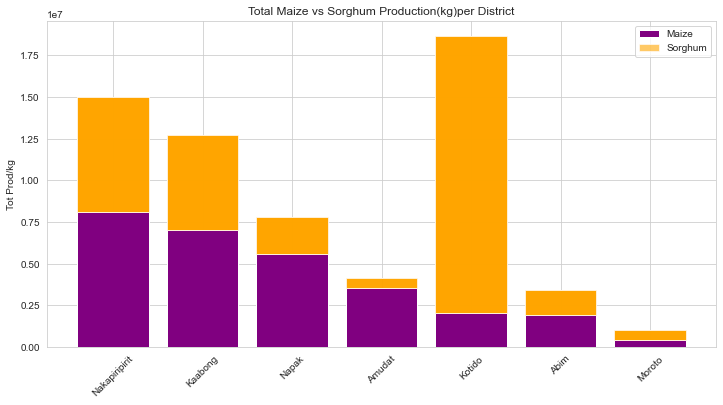

In [82]:
# sorting and assigning the sorted dataframe a new variable for better visualization

karamoja_df_sorted = karamoja_df.sort_values(
    by=["M_Prod_Tot_D", "S_Prod_Tot_D"],
    ascending=[False, False]
)

plt.figure(figsize=(12,6))
plt.bar(karamoja_df_sorted['District'], karamoja_df_sorted["M_Prod_Tot_D"], label="Maize",  color="Purple")
plt.bar(karamoja_df_sorted["District"], karamoja_df_sorted["S_Prod_Tot_D"], bottom=karamoja_df_sorted["M_Prod_Tot_D"], 
        label="Sorghum", alpha=0.6, color="Orange")
plt.xticks(rotation=45)
plt.ylabel("Tot Prod/kg")
plt.title("Total Maize vs Sorghum Production(kg)per District")
plt.legend()
plt.show()

##### **Observation**
Maize production across all district is higher compared to sorghum production,Kitido district has high production in sorghum but Moroto production activity is quite low on both crop production.


In [83]:
karamoja_df.head()

,Object_id,Subcounty,District,Population,Area,Karamoja,S_Yield_Ha,M_Yield_Ha,Crop_Area_Ha,S_Area_Ha,M_Area_Ha,S_Prod_Tot_S,M_Prod_Tot_S,S_Prod_Tot_D,M_Prod_Tot_D,Prod_Per_Capita,Pop_Density,Land_use_efficiency
0,263,Kacheri,Kotido,17244,1067176155,Y,354.207411,1137.467019,7023.533691,6434.342449,528.124229,2.279092e+06,600723.892900,16631904,2010575,116.595627,61886.810195,0.000658
1,264,Kotido,Kotido,52771,597575188,Y,367.890523,1162.996687,13587.990760,12455.592640,824.767081,4.582294e+06,959201.382500,16631904,2010575,38.099998,11323.931478,0.002274
2,265,Kotido Town Council,Kotido,27389,23972401,Y,369.314177,1167.005832,1656.531855,1520.322052,8.561644,5.614765e+05,9991.488268,16631904,2010575,73.408120,875.256526,0.006910
3,266,Nakaperimoru,Kotido,38775,419111591,Y,283.324569,852.366578,7087.823334,6761.488901,45.721712,1.915696e+06,38971.659080,16631904,2010575,51.852353,10808.809568,0.001691
4,267,Panyangara,Kotido,65704,880955930,Y,373.836926,1283.859882,10398.249390,10111.198130,172.611914,3.779939e+06,221609.511400,16631904,2010575,30.600496,13407.949744,0.001180


#### **HISTOGRAM**

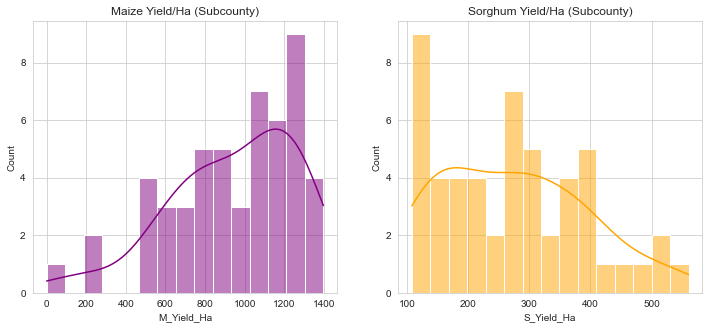

In [84]:
# visualizing using histograms to see the distribution of yeild at a subcounty level for both maize and sorghum

sns.set_style("whitegrid")
fig, axes = plt.subplots(1,2, figsize=(12,5))
sns.histplot(karamoja_df["M_Yield_Ha"], bins=15, kde=True, ax=axes[0], color="Purple")
axes[0].set_title("Maize Yield/Ha (Subcounty)")

sns.histplot(karamoja_df["S_Yield_Ha"], bins=15, kde=True, ax=axes[1], color="Orange")
axes[1].set_title("Sorghum Yield/Ha (Subcounty)")
plt.show()

##### **Observation**
Maize yield has a slightly negative distribution while sorghum yield has slightly positive distibution. 
This means most subcounty produce relatively high maize yields, while only a few have poor performance.Sorghum yields achieve very high productivity.

#### **CORRELATION**

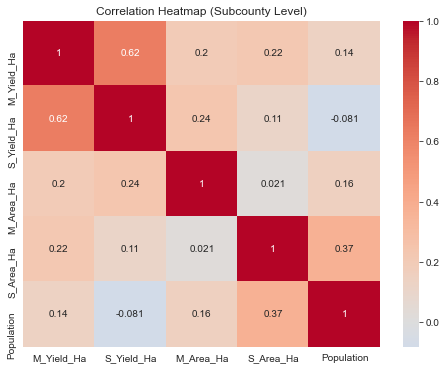

In [85]:
# creating a correlation heatmap to see the relationship between the different variables in the dataset

plt.figure(figsize=(8,6))
sns.heatmap(karamoja_df[["M_Yield_Ha", "S_Yield_Ha", "M_Area_Ha", "S_Area_Ha", "Population"]].corr(), 
            annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Subcounty Level)")
plt.show()

##### **Observation**
Subcounties with high maize yield tend to also have high sorghum yield due argicultural practices.Larger maize area is only weakly associated with higher maize yield.This suggests yield depends more on productivity factors (inputs, rainfall, soil quality) than area size.

#### **EXPORTING**

In [86]:
# saving the cleaned and merged dataframe to a new csv file for future use and analysis
karamoja_df.to_csv('karamoja_df.csv', index=False)